# 🧬 RL_PCB: Advanced EDA Experimentation
This notebook provides a suite of tools for evaluating trained agents, visualizing PCB layouts, and analyzing reward distributions.

---
### 🚀 Setup Environment

In [32]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))

from environment.pcb_env import PCBEnv
from training.config import Config
from evaluation.eval import evaluate

plt.style.use('dark_background')
sns.set_palette("viridis")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 📂 Load Configuration and Model
Specify the path to your training config and the checkpoint you wish to evaluate.

In [33]:
CONFIG_PATH = "configs/base.yaml"
CHECKPOINT_PATH = "runs/checkpoints/ppo_dualstream_step_198656.pt"

config = Config.from_yaml(CONFIG_PATH)
print(f"Loaded Config: {config.board_width}x{config.board_height} Board")

Loaded Config: 32x32 Board


### 📊 Batch Evaluation
Run the agent over multiple boards to collect statistical metrics.

In [34]:
if Path(CHECKPOINT_PATH).exists():
    metrics = evaluate(CHECKPOINT_PATH, config)
    for k, v in metrics.items():
        print(f"{k:25}: {v:.4f}")
else:
    print("Checkpoint not found. Please train a model first!")

NameError: name '_load_model' is not defined

### 🎨 Interactive Visualization
Watch the agent place components one by one on a specific board.

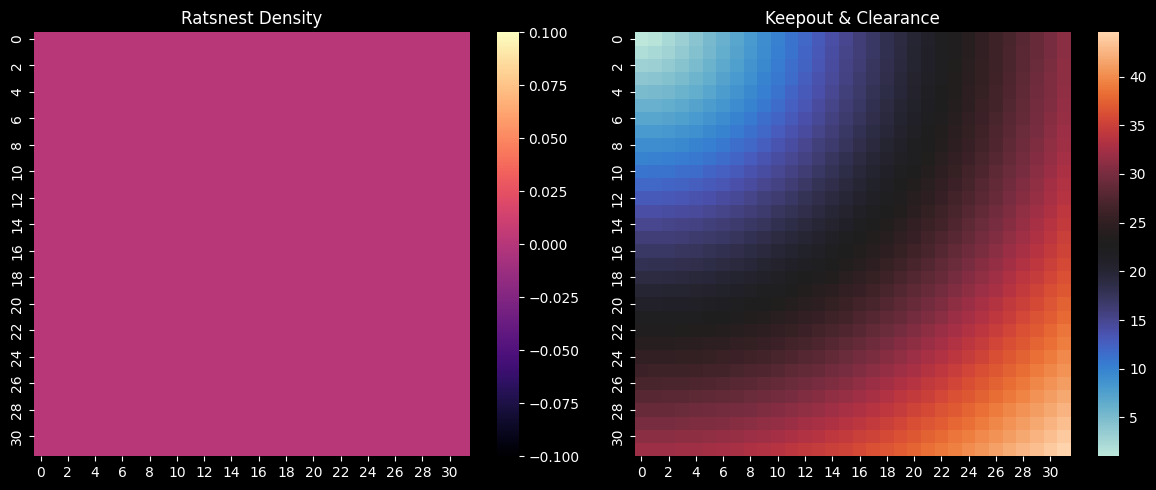

In [ ]:
def visualize_board_state(env):
    obs, info = env._obs_info()
    # Observation typically has SDFs, Ratsnest, etc.
    # We'll visualize the density and keepout for now
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Density Map
    sns.heatmap(obs[-2], ax=axes[0], cmap="magma")
    axes[0].set_title("Ratsnest Density")
    
    # Keepout / Occupied
    sns.heatmap(obs[-3], ax=axes[1], cmap="icefire")
    axes[1].set_title("Keepout & Clearance")
    
    plt.tight_layout()
    plt.show()

env = PCBEnv(board_dir=config.board_dir, width=config.board_width, height=config.board_height)
obs, info = env.reset()
visualize_board_state(env)

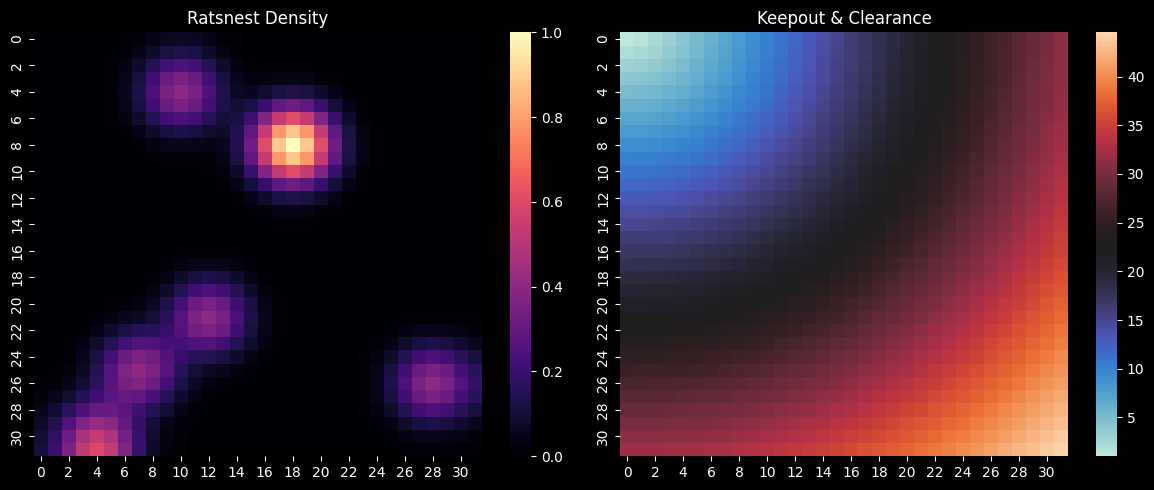

In [ ]:
# 1. Reset the environment
obs, info = env.reset()

# 2. Place all components using random valid actions
terminated = truncated = False
while not (terminated or truncated):
    mask = info["action_mask"]
    valid_indices = np.where(mask)[0]
    
    if len(valid_indices) > 0:
        action = np.random.choice(valid_indices)
        obs, reward, terminated, truncated, info = env.step(action)
    else:
        break

# 3. Visualize the final state
visualize_board_state(env)
